In [1]:

# In this section I am importing all the libraries I will need
#matplotlib tk

import numpy as np
import matplotlib.pyplot as plt


In [2]:
# In this section I am defining variables (arrays) that I would need to implement the method
R = 0.02
n_theta = 30
Nr = 80
Ntheta = 30
dt = 1e-6
t_end = 0.02
save_every = 250
T = 100.0
rho_s = 0.35
u0_amp = 1.0e-3
c = (T / rho_s) ** 0.5
Nt = int(round(t_end / dt)) 

dr = R / Nr
dtheta = 2.0 * np.pi / Ntheta
r = (np.arange(Nr) + 2) * dr
theta = np.arange(Ntheta) * dtheta
Nr = len(r)
Ntheta = len(theta)


In [3]:
# In this section I am setting the boundary conditions/initial values
A = u0_amp
u_p0 = np.zeros((Nr, Ntheta))
for i in range(Nr):
    u_p0[i, :] = A * (1.0 - (r[i] / R) ** 2)
u_p0[-1, :] = 0.0

In [ ]:

# Laplacian

def compute_laplacian_polar(u, r, dr, dtheta):
    Nr, Ntheta = u.shape
    lap = np.zeros_like(u)

    for i in range(Nr - 1):
        ri = r[i]
        for j in range(Ntheta):
            j_plus = (j + 1) % Ntheta
            j_minus = (j - 1) % Ntheta
            u_thetatheta = (u[i, j_plus] - 2.0 * u[i, j] + u[i, j_minus]) / (dtheta**2)
            if i == 0:
                du_dr = (u[i + 1, j] - u[i, j]) / dr
                u_rr = (u[i + 2, j] - 2.0 * u[i + 1, j] + u[i, j]) / (dr**2)
            else:
                du_dr = (u[i + 1, j] - u[i - 1, j]) / (2.0 * dr)
                u_rr = (u[i + 1, j] - 2.0 * u[i, j] + u[i - 1, j]) / (dr**2)
            lap[i, j] = u_rr + (1.0 / ri) * du_dr + (1.0 / (ri**2)) * u_thetatheta
 
    return lap

lap_u0 = compute_laplacian_polar(u_p0, r, dr, dtheta)
u_p1 = u_p0 + 0.5 * ((c * dt) ** 2) * lap_u0
u_p1[-1, :] = 0.0
Nsaved = (Nt // save_every) + 1
if Nt % save_every != 0:
    Nsaved += 1
u_history = np.zeros((Nr, Ntheta, Nsaved))
u_history[:, :, 0] = u_p0
t_history = [0.0]
i_history = 1
center_history = [u_p0[0, 0]]
t_centre = [0.0]
for step in range(1, Nt + 1):
    current_time = step * dt
    center_history.append(u_p1[0, 0])
    t_centre.append(current_time)
    if (step % save_every == 0) or (step == Nt):
        u_history[:, :, i_history] = u_p1
        t_history.append(current_time)
        i_history += 1
    if step < Nt:
        lap_u = compute_laplacian_polar(u_p1, r, dr, dtheta)
        u_p2 = 2.0 * u_p1 - u_p0 + ((c * dt) ** 2) * lap_u
        u_p2[-1, :] = 0.0
        u_p0 = u_p1
        u_p1 = u_p2



DFT calculation for 81 points.


In [8]:
# In this section I am doing any post-processing (if needed)
# Fourier Functions

def DFT(yn):
    N = len(yn)
    w = 2 * np.pi / N
    FTk = np.zeros(N, dtype=complex)
    for k in range(0, N):
        for n in range(0, N):
            # DFT definition X_k = sum(x_n * exp(-i*k*w*n))。
            FTk[k] += np.exp(-1j * k * w * n) * yn[n]
    return FTk

def Transform(u_history, Nr, dt):
 
    # Select an observation node at the middle radius, theta = 0
    r_idx = Nr // 2
    theta_idx = 0

    time_signal = u_history[r_idx, theta_idx, :]

    N = len(time_signal)
    print(f"DFT calculation for {N} points.")


    u_fft = DFT(time_signal)

    # We slice up to N // 2 because, for real-valued input signals, the second half of the DFT spectrum is just a symmetric mirror (Nyquist-Shannon theorem).
    u_amplitude = np.abs(u_fft[:N // 2])

    fs = 1.0 / (dt * save_every)
    freq_axis = np.linspace(0, fs / 2, N // 2)

    # For plotting outside this function
    return freq_axis, u_amplitude, r_idx, theta_idx

freq_axis, u_amplitude, r_idx, theta_idx = Transform(u_history, Nr, dt)



DFT calculation for 81 points.


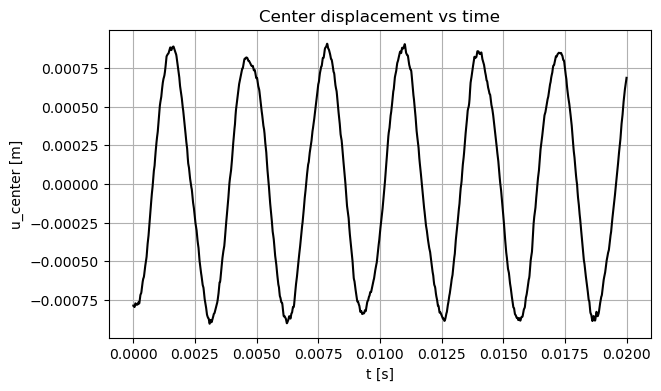

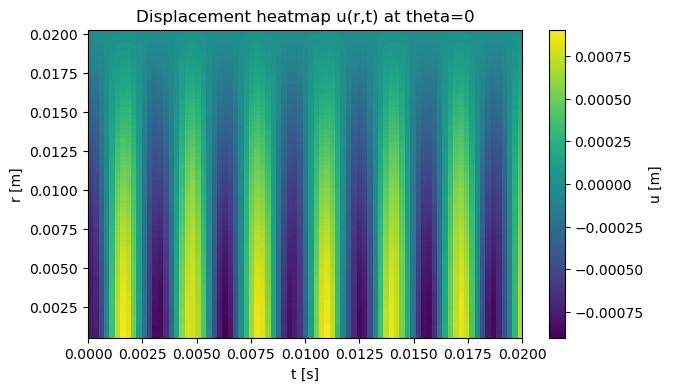

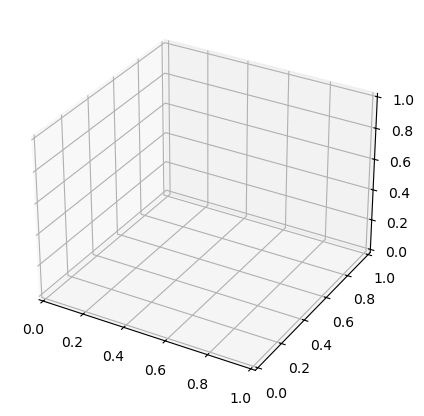

Dominant Frequency: 307.69 Hz
Peak Amplitude: 0.0147


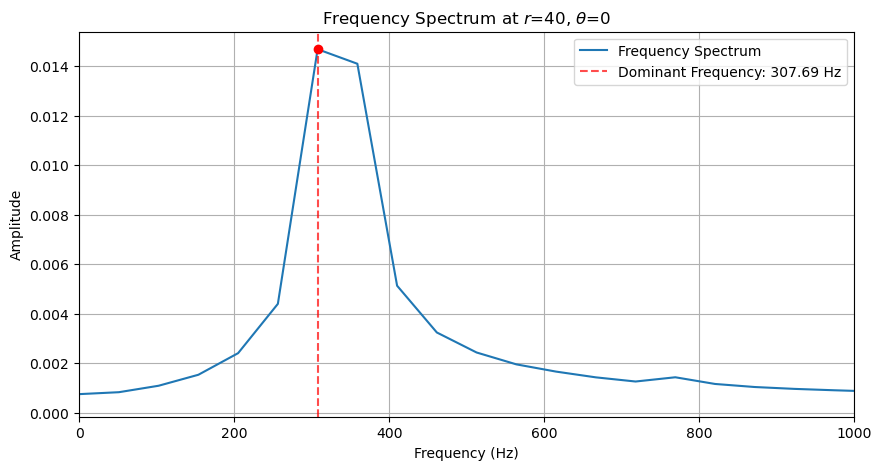

In [9]:
# In this section I am showing/plotting the results

# Build x-y coordinates from polar grid for physical plotting in the membrane plane.
theta_closed = np.append(theta, theta[0] + 2.0 * np.pi)
theta_grid, r_grid = np.meshgrid(theta_closed, r)
x = r_grid * np.cos(theta_grid)
y = r_grid * np.sin(theta_grid)

# Line plot: displacement of membrane center over time.
plt.figure(figsize=(7, 4))
plt.plot(t_centre, center_history, color="black", linewidth=1.5)
plt.title("Center displacement vs time")
plt.xlabel("t [s]")
plt.ylabel("u_center [m]")
plt.grid(True)
plt.show(block=True)
plt.close()

# r-t Heatmap, x-axis is t,y-axis is r, different colour shows u(r,t)
u_rt = u_history[:, 0, :]
plt.figure(figsize=(7, 4))
plt.imshow(
    u_rt,
    origin="lower",
    aspect="auto",
    extent=[t_history[0], t_history[-1], r[0], r[-1]],
    cmap="viridis",
)
plt.colorbar(label="u [m]")
plt.title("Displacement heatmap u(r,t) at theta=0")
plt.xlabel("t [s]")
plt.ylabel("r [m]")
plt.show(block=True)
plt.close()

# Animation of membrane shape as time progress

N_saved_frames = u_history.shape[2]
anim_step = max(1, N_saved_frames // 300)
u_max = np.max(np.abs(u_history))
if u_max < 1.0e-12:
    u_max = 1.0e-12
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")
plt.show(block=False)
for saved_idx in range(0, N_saved_frames, anim_step):
    ax.clear()
    frame_u = u_history[:, :, saved_idx]
    frame_u_closed = np.hstack((frame_u, frame_u[:, :1]))
    ax.plot_surface(x, y, frame_u_closed, cmap="plasma", linewidth=0.0, antialiased=True)
    ax.set_title(f"Membrane animation at t={t_history[saved_idx]:.4f} s")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_zlabel("u [m]")
    ax.set_zlim(-u_max, u_max)
    plt.pause(0.03)
plt.show(block=True)
plt.close(fig)

# Plot Fourier spectrum
plt.figure(figsize=(10, 5))
plt.plot(freq_axis, u_amplitude, label="Frequency Spectrum", linewidth=1.5)
plt.title(rf"Frequency Spectrum at $r$={r_idx}, $\theta$={theta_idx}")

plt.xlim(0, 1000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.grid(True)

dominant_idx = np.argmax(u_amplitude[1:]) + 1
dominant_freq = freq_axis[dominant_idx]

plt.scatter(dominant_freq, u_amplitude[dominant_idx], color="red", zorder=5)
plt.axvline(
    x=dominant_freq,
    color="red",
    linestyle="--",
    alpha=0.7,
    label=rf"Dominant Frequency: {dominant_freq:.2f} Hz",
)

plt.legend(loc="upper right")

print(f"Dominant Frequency: {dominant_freq:.2f} Hz")
print(f"Peak Amplitude: {u_amplitude[dominant_idx]:.4f}")

plt.show(block=True)
plt.close()


In [7]:
# In this section I am celebrating
print('DONE. Finally...')

DONE. Finally...
